In [1]:
from frameworks.LightenDiffusion.models.LightenDiffusion import Stage1
from dataset_registery.registery import DatasetManager
from frameworks.LightenDiffusion.models.decom import ImageEncoder, ImageDecoder, RetinexDecomposition
from eda.helpers.data_helpers import split_dataloader
from frameworks.LightenDiffusion.visualization.visualize_stage1 import visualize_stage1_results
from evaluation.lighten_diffusion_stage1 import evaluate_stage1_metrics_individual
import os
import torch
import pandas as pd
from IPython.display import display

%load_ext autoreload
%autoreload 2

In [2]:
data_name = "SICE_paired"
dataset_id = "okhater/SICE"
source = "huggingface"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_VISUALIZATION_SAMPLES = 4
print(f"Device used : {device}")

Device used : cuda


In [3]:
registry = DatasetManager()
registry.initialize_dataset(
    name=data_name,
    dataset_id=dataset_id,
    splits=["train", "test"],
    dataset_type="paired",
    hf_cache_dir=f"../../datasets/{data_name}",
)

train_loader = registry.get_dataloader(data_name, "train", batch_size=16, shuffle=True)
test_loader = registry.get_dataloader(data_name, "test", batch_size=16, shuffle=True)
train_loader, val_loader = split_dataloader(train_loader, split_ratio=0.2)

loaders = {
    "train": train_loader, 
    "val": val_loader, 
    "test": test_loader
    }
for name, loader in loaders.items():
    total_samples = len(loader.dataset)
    print(f"Loader: {name}, Total samples: {total_samples}")
    for low_imgs, label in loader:
        print(f"Batch contains {len(low_imgs)} low image samples.")
        print("Low images batch shape:", low_imgs.shape)
        print("Label batch shape:", label.shape)
        break
    print("==="*20)

Resolving data files:   0%|          | 0/1280 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/223 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1280 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/223 [00:00<?, ?it/s]

Loader: train, Total samples: 207
Batch contains 16 low image samples.
Low images batch shape: torch.Size([16, 2, 3, 256, 256])
Label batch shape: torch.Size([16, 3, 256, 256])
Loader: val, Total samples: 51
Batch contains 16 low image samples.
Low images batch shape: torch.Size([16, 2, 3, 256, 256])
Label batch shape: torch.Size([16, 3, 256, 256])
Loader: test, Total samples: 46
Batch contains 16 low image samples.
Low images batch shape: torch.Size([16, 2, 3, 256, 256])
Label batch shape: torch.Size([16, 3, 256, 256])


In [4]:
directory = "/home/grads/o/omarkhater/projects/lle-generative-priors/frameworks/LightenDiffusion/trained_models/stage1/"
file_path = os.path.join(directory, "stage1_beta2.pth")
if not os.path.exists(file_path):
    raise FileNotFoundError(f"File not found: {file_path}")
stage1_model_weights = torch.load(file_path, map_location=device)


stage1_model = Stage1(
    encoder=ImageEncoder(64),
    decoder=ImageDecoder(64),
    decomposer=RetinexDecomposition(),
)

stage1_model.load_state_dict(stage1_model_weights)

<All keys matched successfully>

## Approach 2: Individual Evaluation ("Per-Image")
- **Method:**  
  Compute the metrics for each of the m reconstructions individually, then average the metric values across all m outputs.

- **Paired Evaluation (with reference):**  
  For each reconstruction, metrics (PSNR, SSIM, LPIPS, NIQE, and PI) are computed against the ground truth, and the results are averaged over m.

- **Unpaired Evaluation (no reference):**  
  Each reconstruction’s NIQE is computed and then averaged. Additionally, the consistency metric (average pairwise LPIPS) is calculated across all m reconstructions.

### Quantitive Evaluation

#### Train

In [5]:
metrics_train_PI = evaluate_stage1_metrics_individual(stage1_model,train_loader)

Evaluating Stage1 (Individual):   0%|          | 0/13 [00:00<?, ?it/s]/home/grads/o/omarkhater/projects/lle-generative-priors/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/grads/o/omarkhater/projects/lle-generative-priors/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Evaluating Stage1 (Individual): 100%|██████████| 13/13 [05:09<00:00, 23.80s/it]


#### Test

In [6]:
metrics_test_PI = evaluate_stage1_metrics_individual(stage1_model,test_loader)

Evaluating Stage1 (Individual): 100%|██████████| 3/3 [01:10<00:00, 23.40s/it]


### Qualitive Evaluation

#### Train

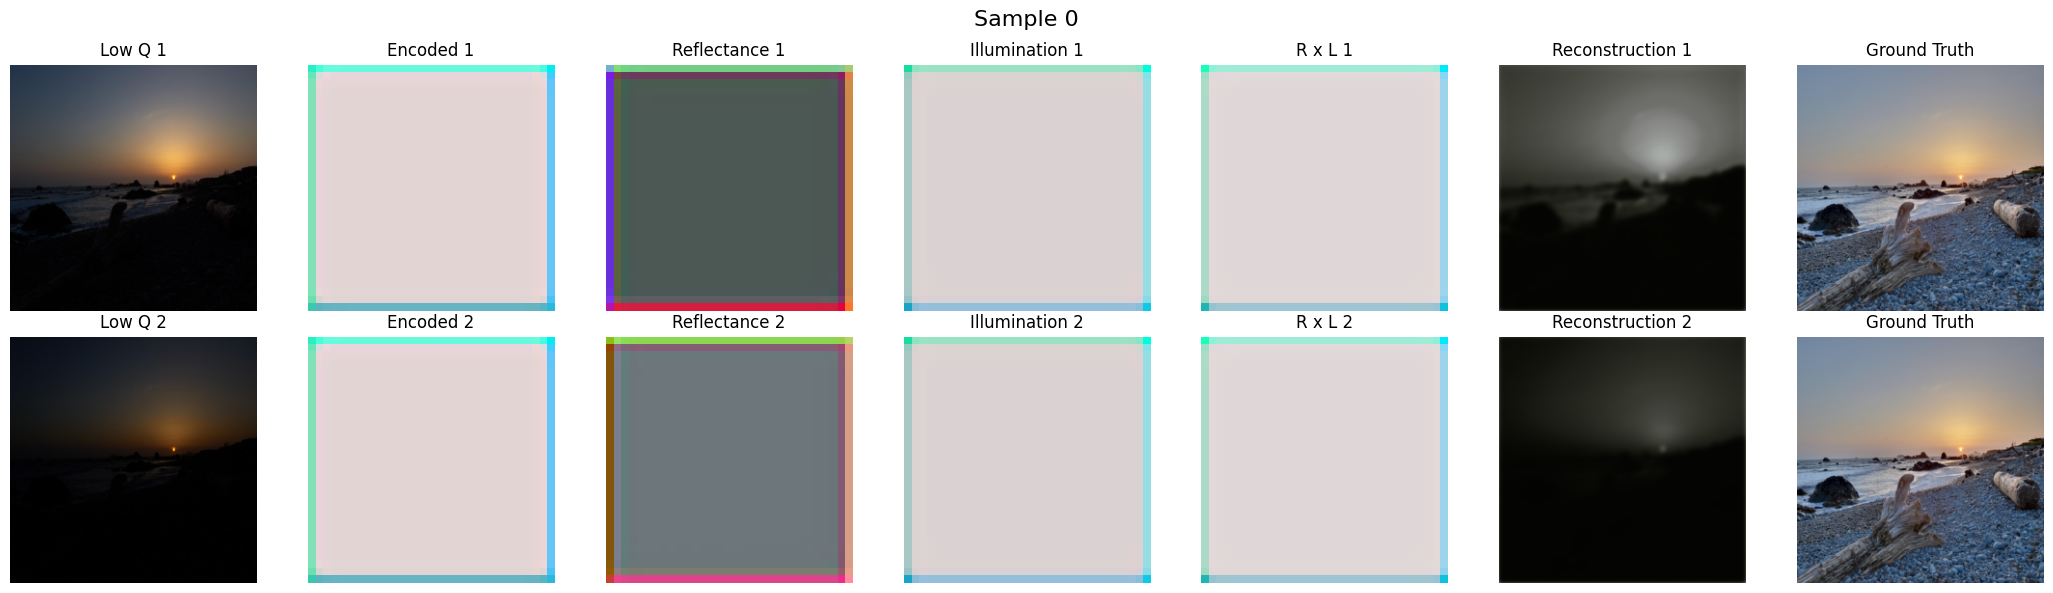

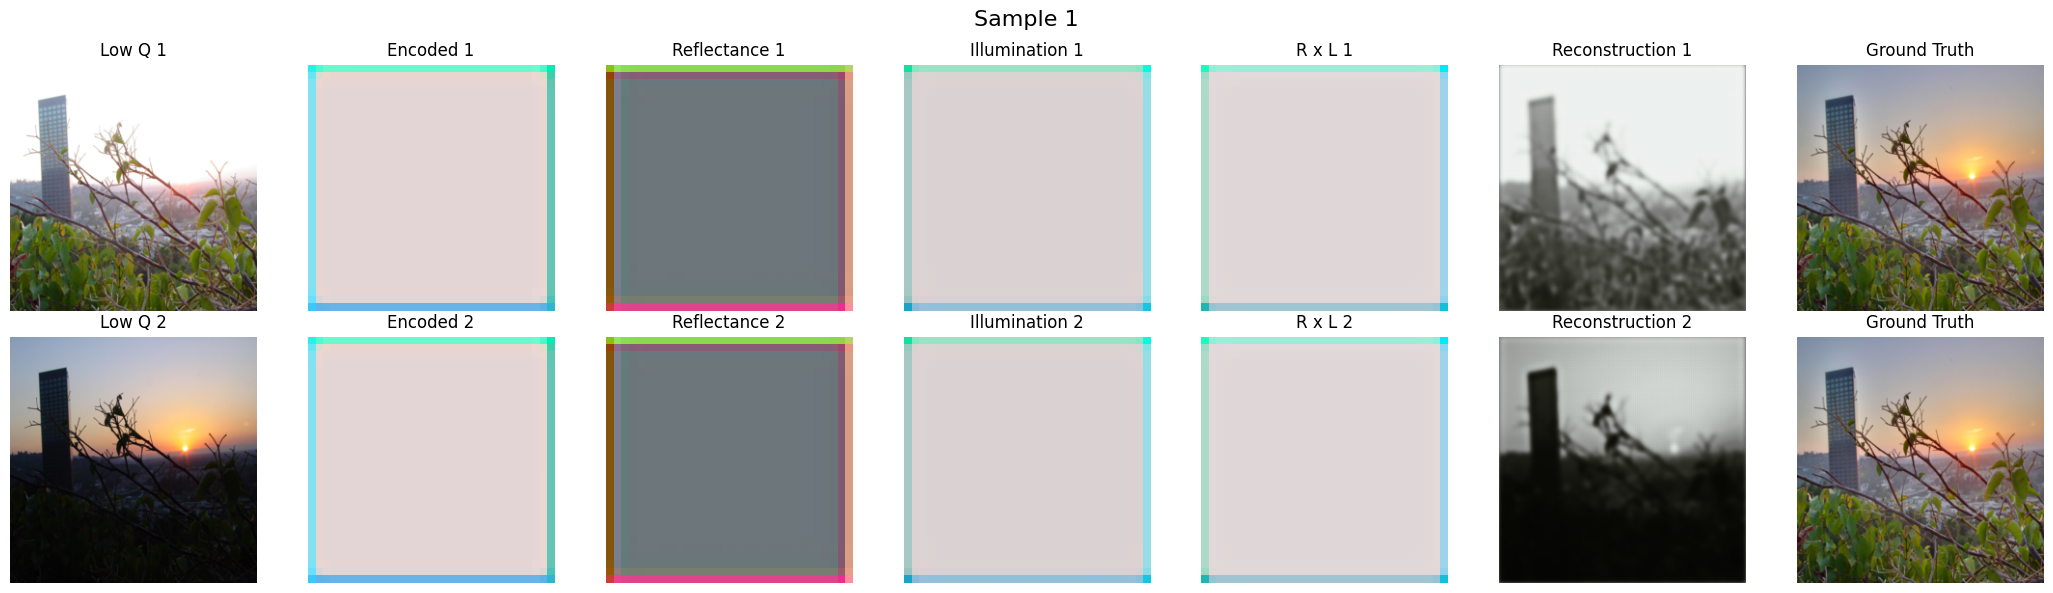

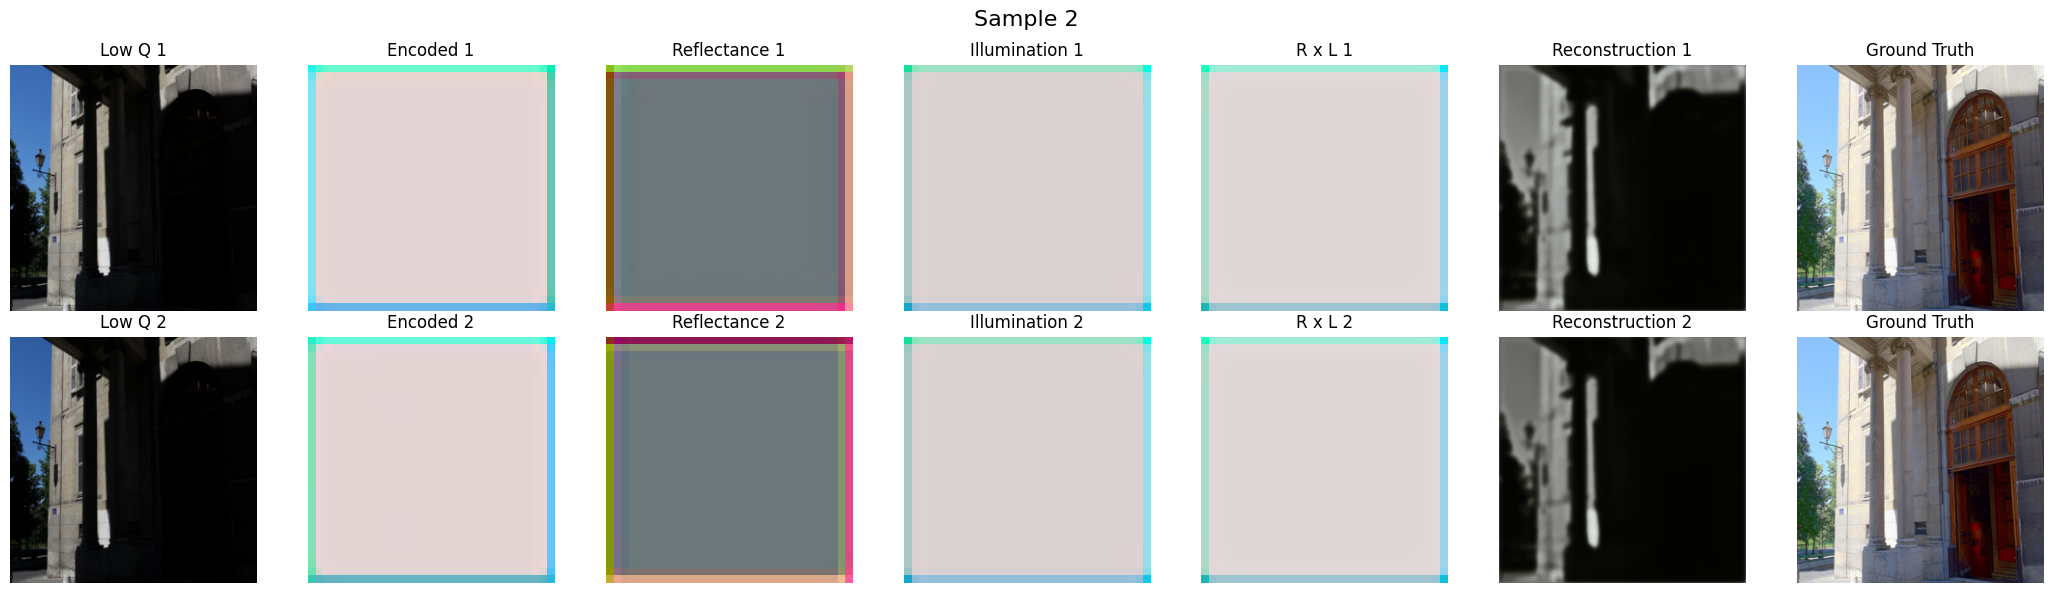

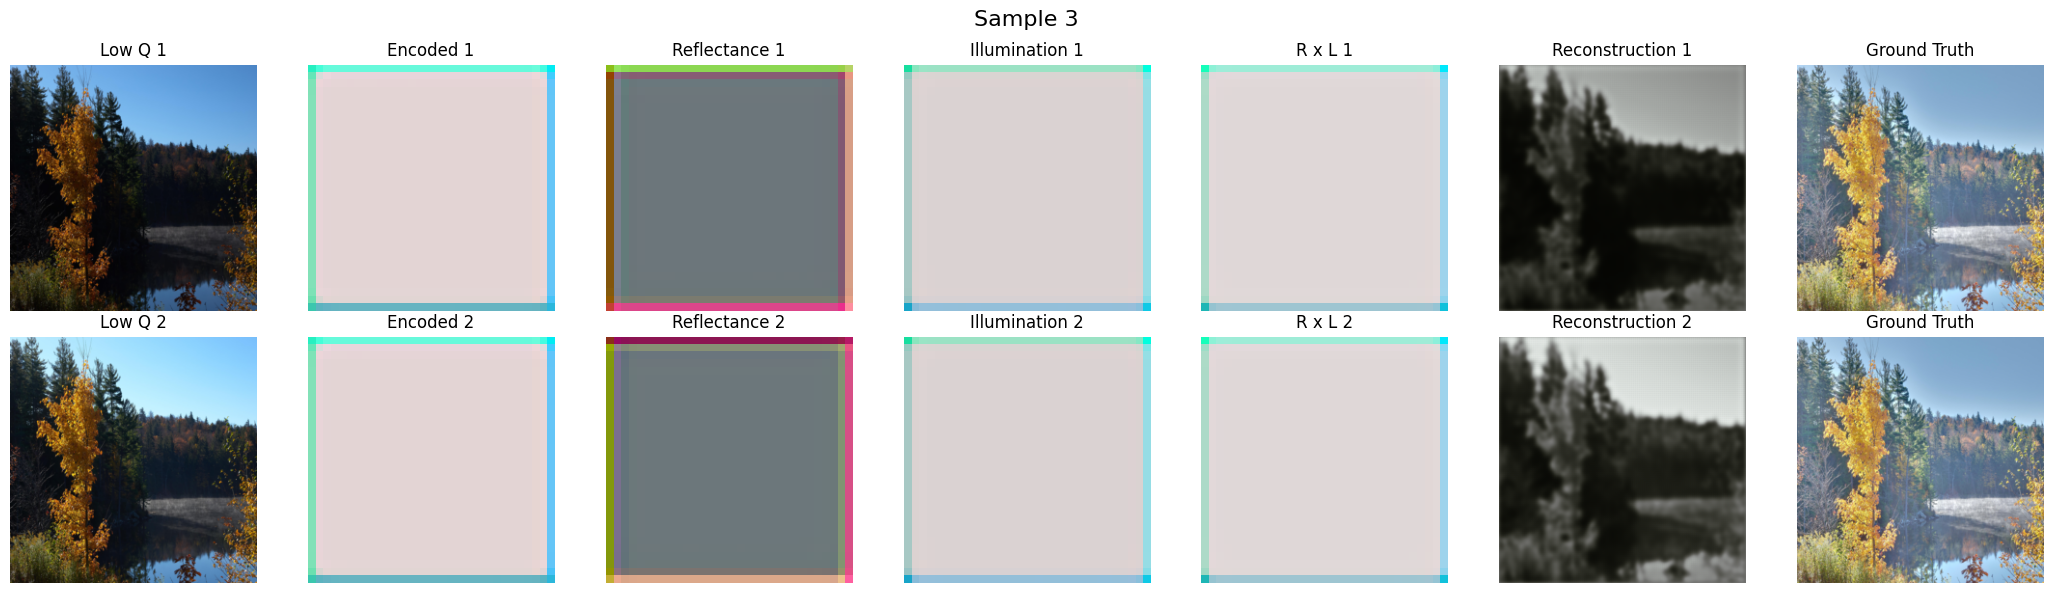

In [7]:
visualize_stage1_results(
    stage1_model,
    train_loader,
    num_samples = NUM_VISUALIZATION_SAMPLES,
)

#### Test

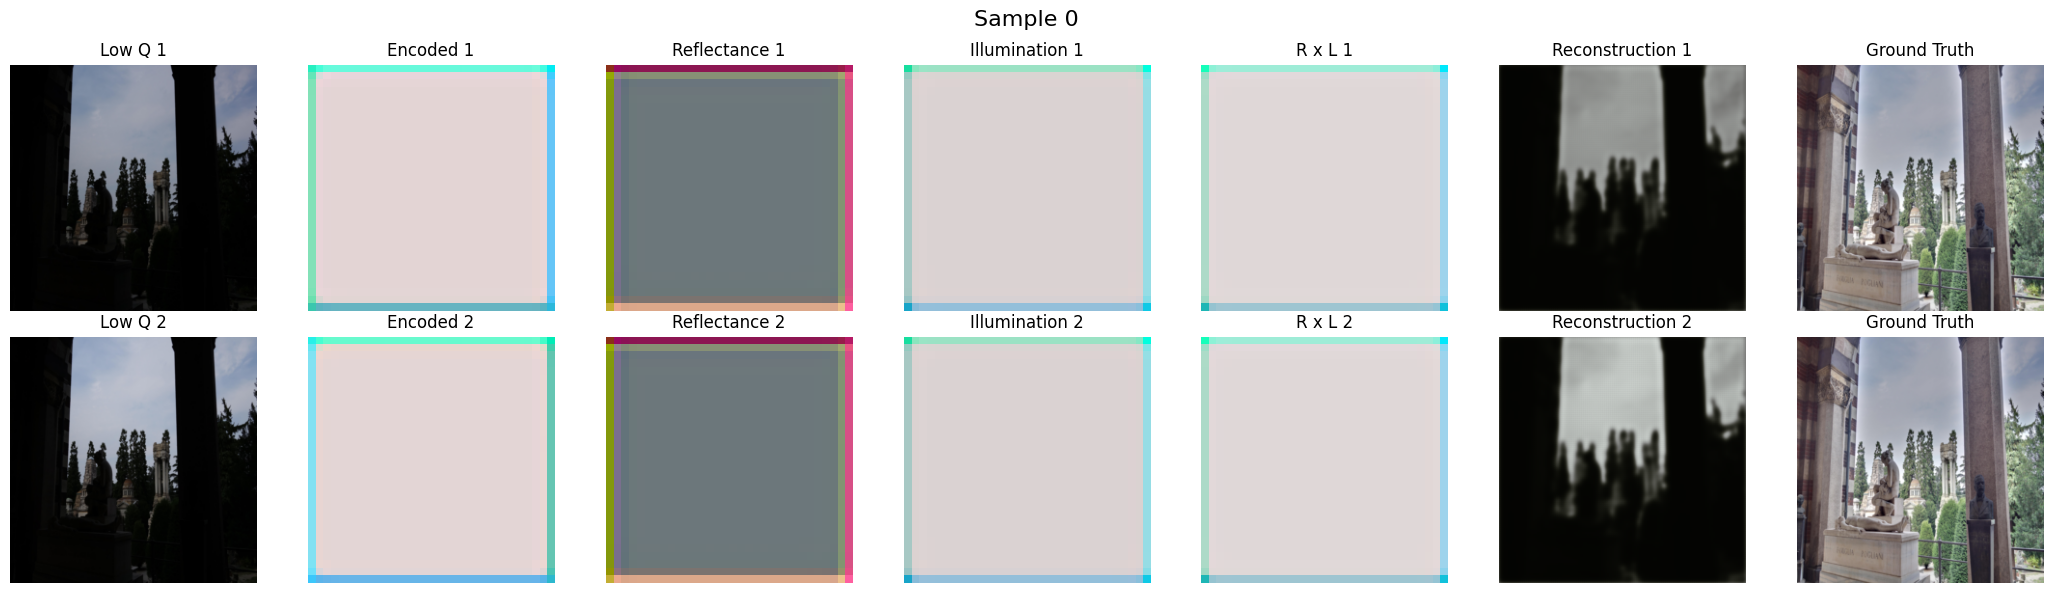

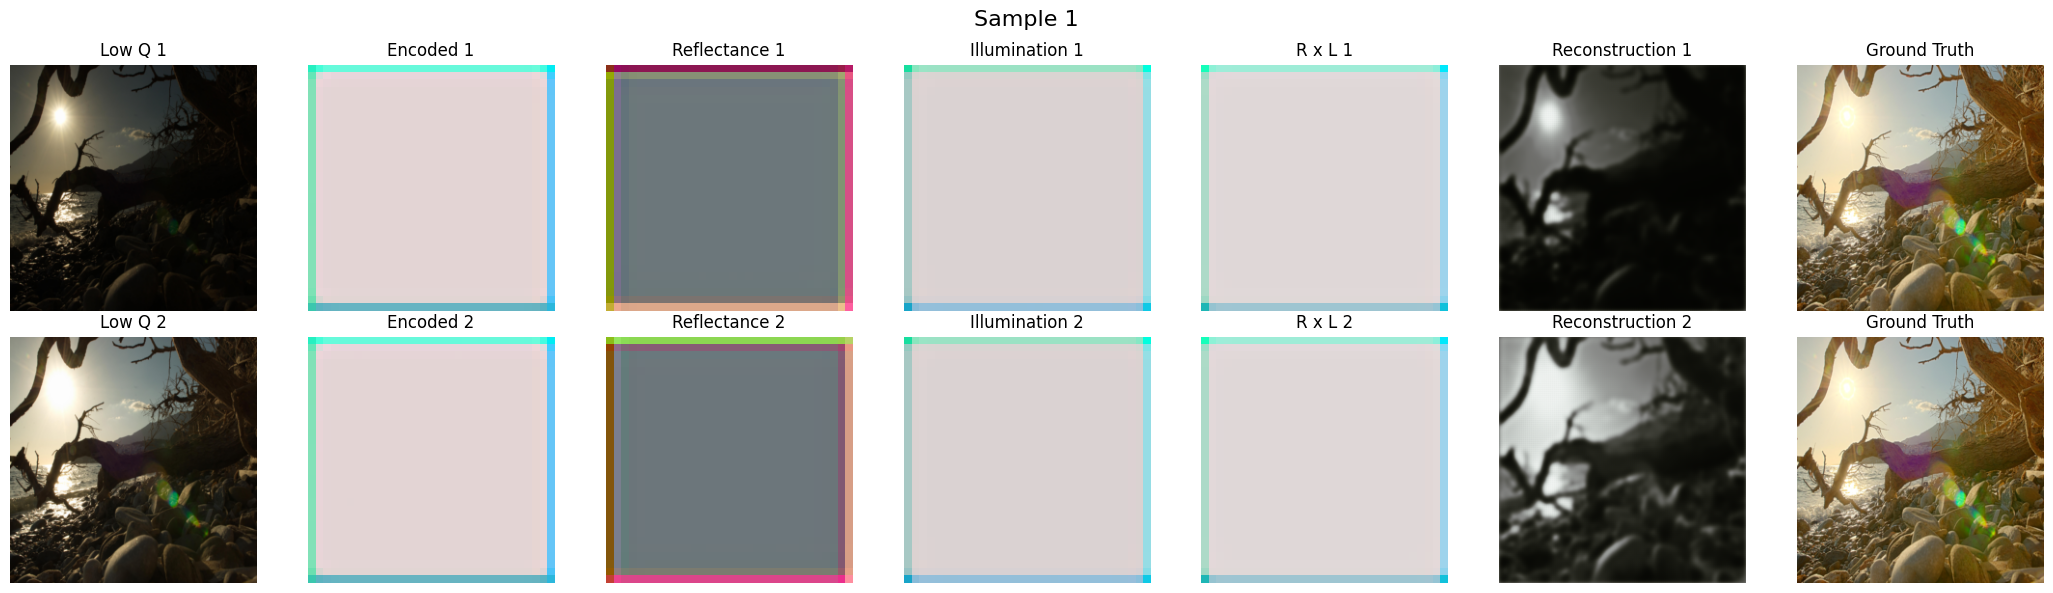

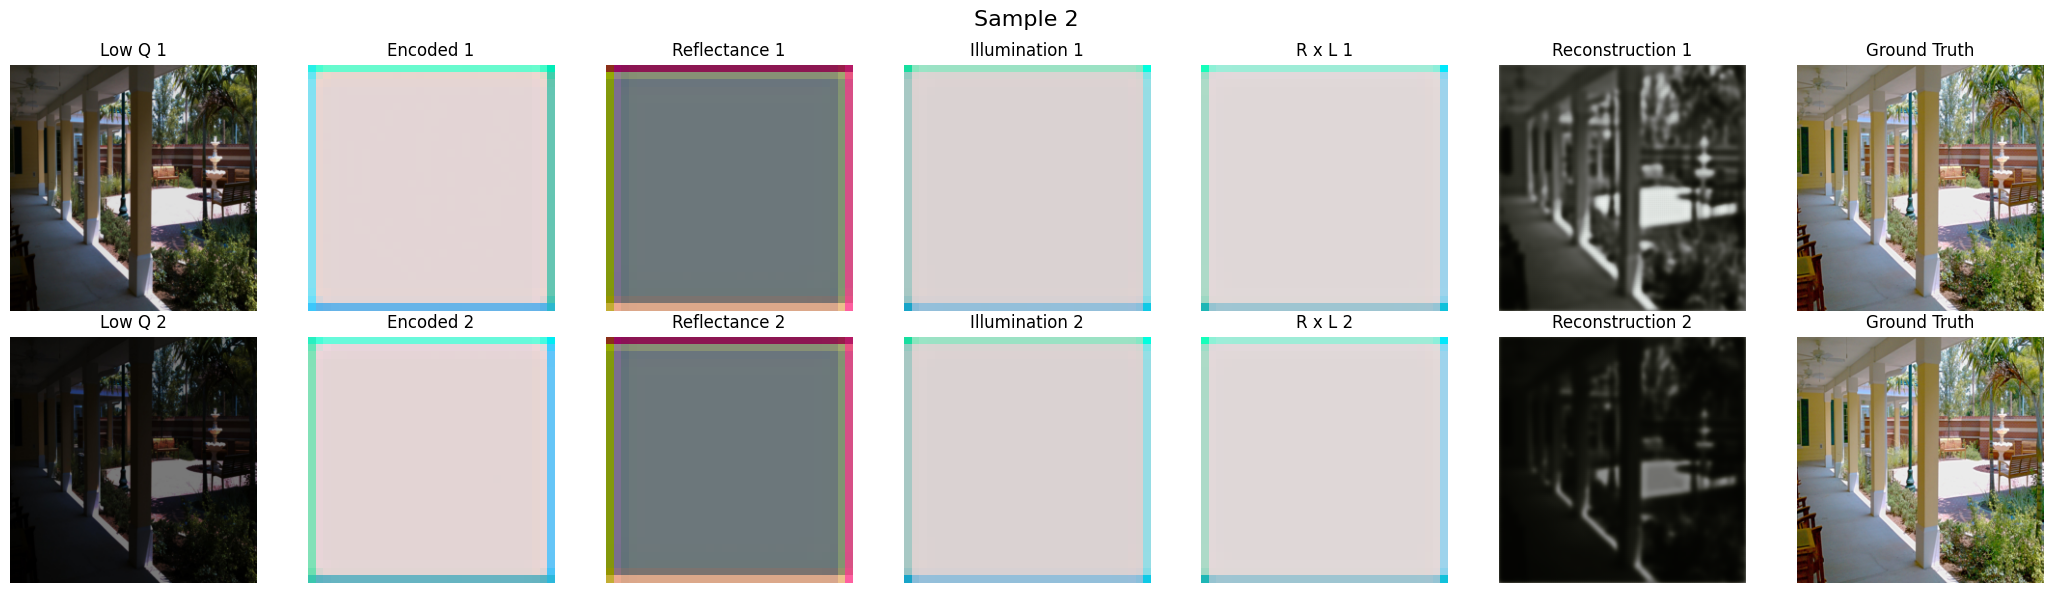

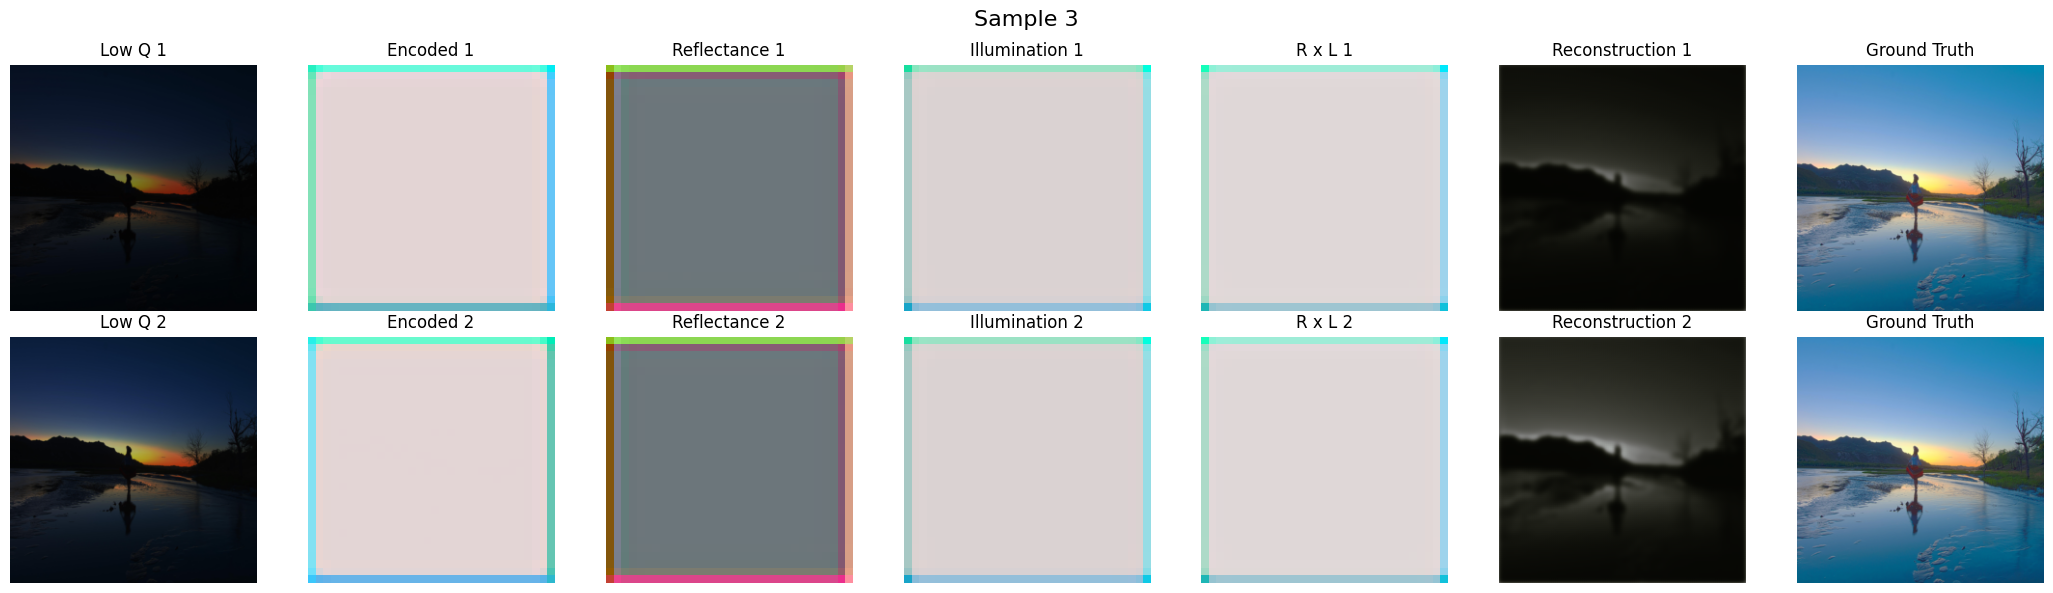

In [8]:
visualize_stage1_results(
    stage1_model,
    test_loader,
    num_samples = NUM_VISUALIZATION_SAMPLES,
)

## Summary 

In [9]:
results_df = pd.DataFrame({
    "train_Per_Image": metrics_train_PI,
    "test_Per_Image": metrics_test_PI
})
display(results_df)

,train_Per_Image,test_Per_Image
psnr,20.484889,20.564806
ssim,0.624715,0.642816
lpips,0.612037,0.557835
niqe,11.389984,11.071024
pi,6.001011,5.814429
tv_illumination,0.022892,0.022892
reflectance_consistency,0.027198,0.026706
